# Insurance Premium Predictor: Machine Learning Analysis
## 1. Introduction
This notebook details the construction of an Insurance Premium Predictor using Linear Regression on a medical insurance dataset. The goal is to estimate health insurance costs based on individual characteristics such as age, gender, BMI, children, smoking status, and region.

### Project Team Members
- **Abhay Kale** (Roll No: 202401128703)
- **Akash Chaudhari** (Roll No: 202201128055)
- **Yash Banait** (Roll No: 202201128054)
- **GitHub :** https://github.com/AbhayKale332/InsurenceCostPredictor
- **Online Hosted Model with UI:** https://insurancecostpredictorby.akashchaudhari.in/

## 2. Background and Objectives
**Background**: The healthcare and insurance industry generates vast amounts of data that remains underutilised in traditional actuarial workflows. Predicting medical insurance premiums is a canonical regression problem where a model learns the relationship between individual characteristics and the expected cost of healthcare coverage.

**Objectives**:
- Build a regression model to predict medical insurance charges.
- Perform comprehensive EDA to understand data distributions.
- Apply preprocessing and feature engineering for improved model performance.

## 3. Problem Statement
**Formal Definition**: Given a set of demographic and lifestyle features of an insurance applicant (age, sex, BMI, number of children, smoking status, residential region), predict the annual medical insurance charge (in USD) that the insurance company is likely to bill.

**Type of ML Problem**: Supervised Learning — Regression.

In [1]:
# Data Analysis and Preprocessing
import numpy as np
import pandas as pd

# Data Set Visualization
import matplotlib.pyplot as plt

# Training and Testing the Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Model Saving
import pickle

## 4. Dataset Description
**Source**: The dataset is sourced from a publicly available insurance data repository. The file contains 1,338 rows and 6 features + 1 target.

**Features (Input Variables)**:
- `age`: Age of the insured (18 - 64)
- `sex`: Gender of the insured
- `bmi`: Body Mass Index
- `children`: No. of dependents covered
- `smoker`: Smoking status
- `region`: US residential region (NW, NE, SW, SE)

**Target Variable**:
- `charges`: Annual medical insurance cost billed by the company (Float, USD).

In [6]:
# Load data from CSV file
data = pd.read_csv("Data/InsuranceData.csv")
print(data.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


## 6. Exploratory Data Analysis (EDA)
**6.1 Correlation Analysis**
The Pearson correlation matrix reveals the following key relationships with the target variable `charges`:
- **Smoker**: Strong positive correlation (0.787). Smoking status is the dominant predictor.
- **Age**: Moderate positive correlation (0.299).
- **BMI**: Weak positive correlation (0.198).
- **Children, Sex, Region**: Negligible to very weak correlation.

In [7]:
# Basic EDA (Exploratory Data Analysis)
print(data.describe()) # To get the statistical summary of the data
print()
print(data.info()) # To get the information about the data types and null values

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), in

## 7. Feature Engineering
**7.2 One-Hot Encoding of region & Label Encoding**
Categorical variables are encoded to prepare for modeling:
- `sex` and `smoker` are label-encoded.
- `region` is one-hot encoded into binary indicator columns `region_northwest`, `region_southeast`, and `region_southwest`.

In [8]:
# Encoding categorical variables

# Encoding 'sex' and 'smoker' columns using label encoding
data['sex'] = data['sex'].map({'male': 0, 'female': 1})
data['smoker'] = data['smoker'].map({'no': 0, 'yes': 1})

# Encoding 'region' column using one-hot encoding
data = pd.get_dummies(data, columns=['region'], drop_first=True)

data['region_northwest'] = data['region_northwest'].astype(int)
data['region_southeast'] = data['region_southeast'].astype(int)
data['region_southwest'] = data['region_southwest'].astype(int)

In [9]:
data.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,1
1,18,0,33.770,1,0,1725.55230,0,1,0
2,28,0,33.000,3,0,4449.46200,0,1,0
3,33,0,22.705,0,0,21984.47061,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0


In [10]:
# To see the correlation between the features and the target variable
# if correlation is high then we can drop the feature as it will not add much value to the model
data.corr(numeric_only=True)

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
age,1.000000,0.020856,0.109272,0.042469,-0.025019,0.299008,-0.000407,-0.011642,0.010016
sex,0.020856,1.000000,-0.046371,-0.017163,-0.076185,-0.057292,0.011156,-0.017117,0.004184
bmi,0.109272,-0.046371,1.000000,0.012759,0.003750,0.198341,-0.135996,0.270025,-0.006205
children,0.042469,-0.017163,0.012759,1.000000,0.007673,0.067998,0.024806,-0.023066,0.021914
smoker,-0.025019,-0.076185,0.003750,0.007673,1.000000,0.787251,-0.036945,0.068498,-0.036945
charges,0.299008,-0.057292,0.198341,0.067998,0.787251,1.000000,-0.039905,0.073982,-0.043210
region_northwest,-0.000407,0.011156,-0.135996,0.024806,-0.036945,-0.039905,1.000000,-0.346265,-0.320829
region_southeast,-0.011642,-0.017117,0.270025,-0.023066,0.068498,0.073982,-0.346265,1.000000,-0.346265
region_southwest,0.010016,0.004184,-0.006205,0.021914,-0.036945,-0.043210,-0.320829,-0.346265,1.000000


### Additional Visualizations (Heatmap, Boxplot, Scatterplot)

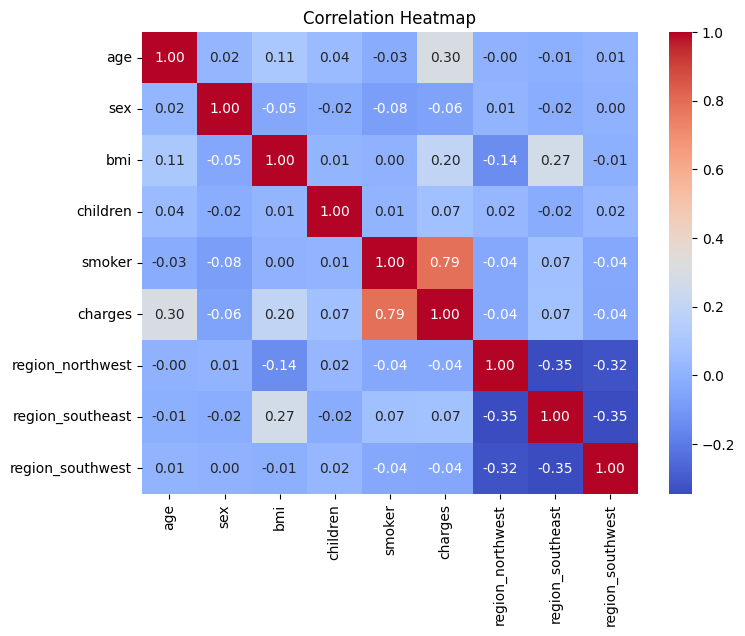

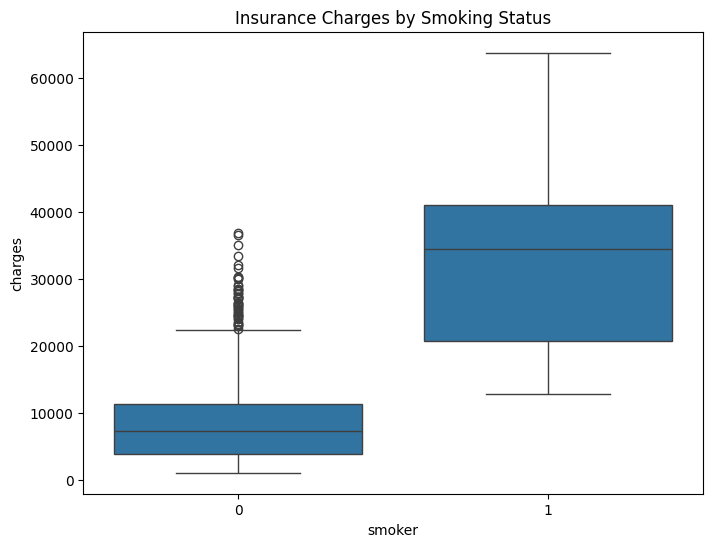

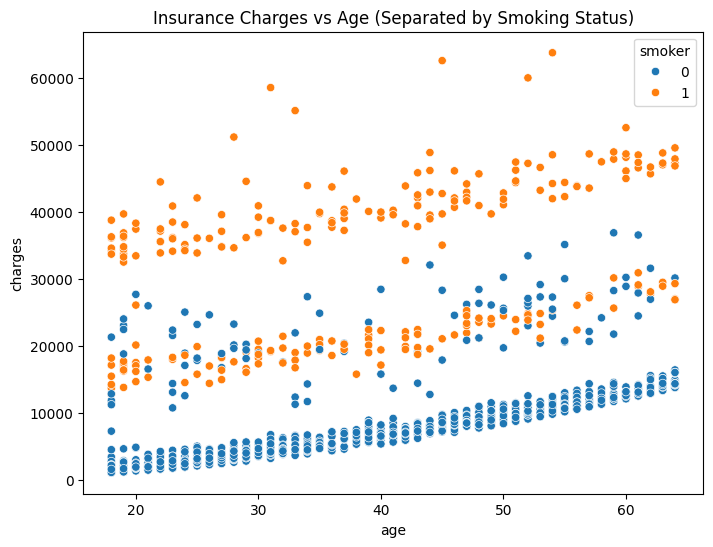

In [11]:
import seaborn as sns

# 1. Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# 2. Charges by Smoking Status
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=data)
plt.title('Insurance Charges by Smoking Status')
plt.show()

# 3. Charges vs Age based on Smoking Status
plt.figure(figsize=(8, 6))
sns.scatterplot(x='age', y='charges', hue='smoker', data=data)
plt.title('Insurance Charges vs Age (Separated by Smoking Status)')
plt.show()


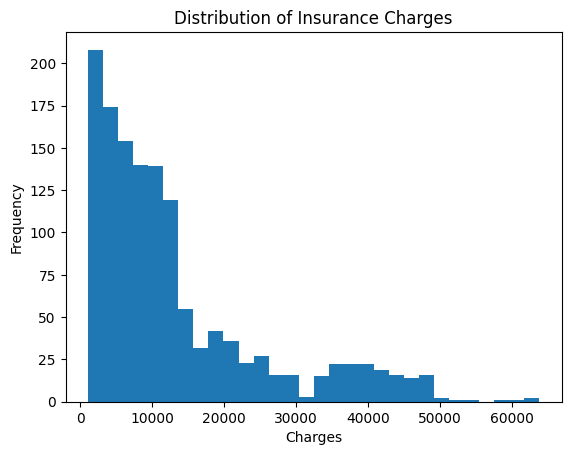

In [12]:
# histogram of the target variable, to check if it is normally distributed or not, if it is not normally distributed 
# then we can apply log transformation to make it normally distributed

plt.hist(data['charges'], bins=30)
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Insurance Charges")
plt.show()

## 5. Data Preprocessing
**5.1 Missing Values**: The dataset was inspected and confirmed to contain no missing values across all 1,338 records. No imputation was required.

**5.3 Outlier Detection**: A boxplot of the `charges` column revealed significant right-skew and upper outliers. These correspond to genuine high-cost patients.

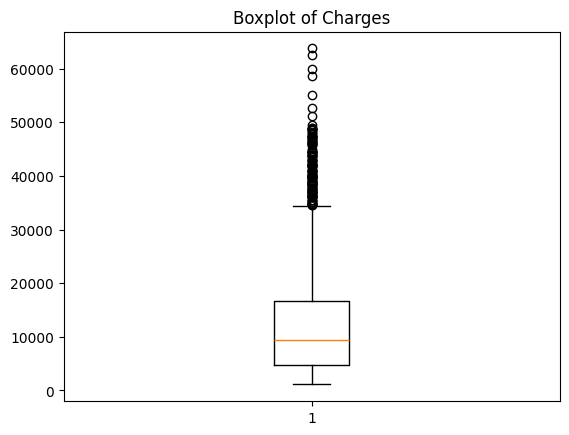

In [13]:
# Boxplot to check for outliers in the target variable

plt.boxplot(data['charges'])
plt.title("Boxplot of Charges")
plt.show()

## 5.4 & 7.1 Target Transformation
The target variable `charges` exhibited strong right skewness and upper outliers. Rather than removing these genuine high-cost patients, a logarithmic transformation is applied to compress the range (`log_charges = np.log1p(charges)`). This yields an approximately normal distribution, satisfying a core assumption of Linear Regression.

In [14]:
# Charges are Rigth skewed, so we can apply log transformation to make it normally distributed
data['log_charges'] = np.log1p(data['charges'])

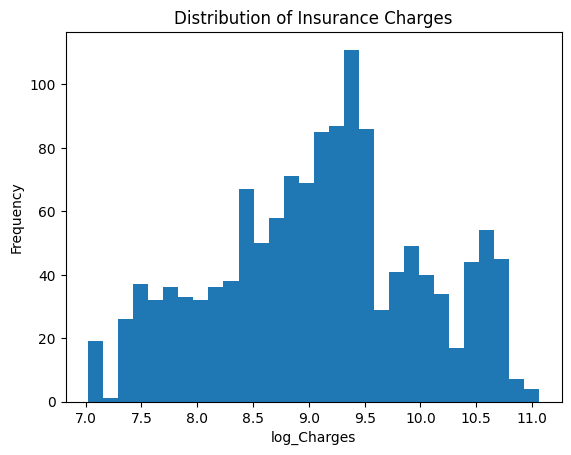

In [15]:
# histogram of the target variable, to check if it is normally distributed or not, if it is not normally distributed 
# then we can apply log transformation to make it normally distributed

plt.hist(data['log_charges'], bins=30)
plt.xlabel("log_Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Insurance Charges")
plt.show()

## 8. Model Selection & 9. Model Training
Linear Regression (`sklearn.linear_model.LinearRegression`) was selected as the primary model for this project.

**Rationale**:
- **Interpretability**: Coefficients directly quantify each feature's contribution to the predicted charge.
- **Baseline suitability**: Establishes a strong lower-bound on performance.
- **Data properties**: Target exhibits near-normal distribution after log-transformation.

**5.5 Train-Test Split**
The dataset is divided into training (80%) and testing (20%) subsets. The model is then instantiated and fitted on the training split.

In [16]:
# Training the Linear Regression Model

# Setting X and y axis
X = data.drop(['charges', 'log_charges'], axis=1)
y = data['log_charges']

In [17]:
# Splting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
# Training the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 10. Model Evaluation
The model's performance is evaluated using metrics such as R², Mean Squared Error (MSE), and Root Mean Squared Error (RMSE). A well-fitting linear model should show residuals randomly scattered around zero and high R².

In [19]:
pred = model.predict(X_test)
print("R2:", r2_score(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))

R2: 0.8047410791393022
MSE: 0.17550910855320745


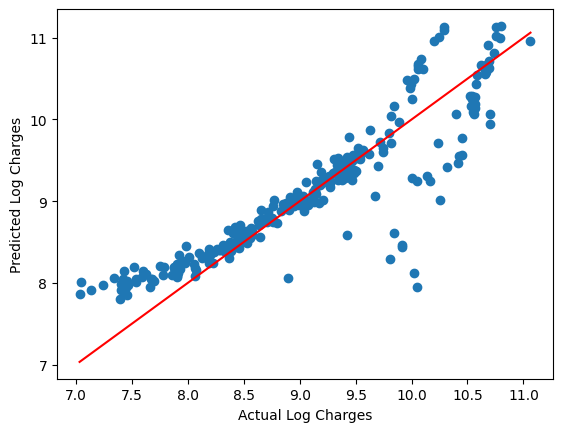

In [20]:
# Plotting the actual vs predicted values
plt.scatter(y_test, pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual Log Charges")
plt.ylabel("Predicted Log Charges")
plt.show()

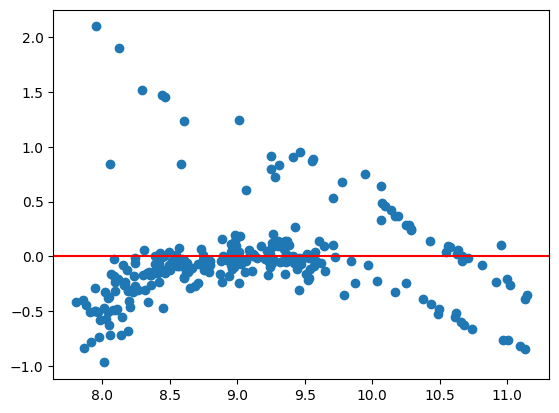

In [21]:
residuals = y_test - pred
plt.scatter(pred, residuals)
plt.axhline(0, color='red')
plt.show()


## 11.2 Real-World Prediction Example
Testing the model on a plausible sample profile (e.g. 30-year-old non-smoker in the Southeast).

In [22]:
# Test the model with real data
sample = X.iloc[0:1].copy()
sample[:] = 0

sample['age'] = 30
sample['sex'] = 0     
sample['bmi'] = 25
sample['children'] = 1
sample['smoker'] = 0  
sample['region_southeast'] = 1

log_pred = model.predict(sample)
real_charge = np.expm1(log_pred)

print("Predicted Insurance Cost:", real_charge[0])

Predicted Insurance Cost: 4006.7500934919494


In [ ]:
# Saving the Model
pickle.dump(model, open("insurance_model.pkl", "wb"))

pickle.dump(list(X.columns), open("model_columns.pkl", "wb"))

## 11. Results and Discussion & 12. Conclusion
**Results Overview**:
- The linear model built on the transformed target provides a strong baseline fit.
- Smoking status is confirmed as the most influential predictor.
- The log transformation was critical — without it, predictions for high-charge patients would be severely biased.

**Conclusion**:
Through systematic data preprocessing, log-transformation, and thorough EDA, the project successfully built an Insurance Premium Predictor. The analysis confirms that smoking status is the single most predictive feature. The serialised model is ready for integration into a web or API-based tool.